# Лабораторна робота №2
## NumPy, pandas i Matplotlib для підготовки, аналізу та візуалізації даних

**Мета:** Ознайомитися з основами роботи з бібліотеками NumPy, Pandas та Matplotlib для аналізу даних, проведення базових операцій з даними та візуалізації результатів.

**Студент:** [Кичата Софія]  
**Група:** [МІТ-21]  
**Варіант:** 11 (відповідає варіанту 1 - Температурний сенсор)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Базові налаштування
seed = 11
a = 0.35
b = 18.0
sigma = 0.8

rng = np.random.default_rng(seed)

### 1. Робота з NumPy
Генерація даних, створення матриці та базові матричні операції.

In [2]:
# 2. Створення масиву x (100 рівномірних значень від 0 до 20)
x = np.linspace(0, 20, 100)

# 3. Обчислення y_hat, шуму та y_observed
y_true = a * x + b
noise = rng.normal(loc=0, scale=sigma, size=x.size)
y_observed = y_true + noise

# 4. Об'єднання у матрицю (100 рядків, 4 стовпці)
matrix = np.column_stack((x, y_true, noise, y_observed))

print(f"Shape (форма): {matrix.shape}")
print(f"Ndim (вимірність): {matrix.ndim}")
print(f"Size (кількість елементів): {matrix.size}")
print(f"Dtype (тип даних): {matrix.dtype}")

# 5. Читання, фільтрація та модифікація
print("\nЧитання через індекс (перший рядок):", matrix[0, :])
print("Читання через зріз (перші 3 рядки, стовпці x та y_observed): \n", matrix[:3, [0, 3]])

# Булева фільтрація (значення y_observed > 24)
high_temp_filter = matrix[matrix[:, 3] > 24]
print(f"\nКількість вимірів з температурою > 24°C: {high_temp_filter.shape[0]}")

# Оновлення копії фрагмента
frag_copy = matrix[:5, :].copy()
frag_copy[0, 3] = 100.0  # Змінюємо значення в копії
print("\nОригінальне значення:", matrix[0, 3], "| Значення в копії:", frag_copy[0, 3])

# Видалення елемента (видаляємо перший рядок)
matrix_deleted = np.delete(matrix, 0, axis=0)
print(f"Форма після видалення першого рядка: {matrix_deleted.shape}")

# 6. Статистика для y_observed
print(f"\nСтатистика y_observed: Мін = {np.min(y_observed):.2f}, Макс = {np.max(y_observed):.2f}")
print(f"Середнє = {np.mean(y_observed):.2f}, Стандартне відхилення = {np.std(y_observed):.2f}")

# Агрегація з axis=0 для всієї матриці (середнє по кожному стовпцю)
print(f"Середнє по всіх стовпцях матриці (axis=0): {np.mean(matrix, axis=0)}")

Shape (форма): (100, 4)
Ndim (вимірність): 2
Size (кількість елементів): 400
Dtype (тип даних): float64

Читання через індекс (перший рядок): [ 0.         18.          0.02735421 18.02735421]
Читання через зріз (перші 3 рядки, стовпці x та y_observed): 
 [[ 0.         18.02735421]
 [ 0.2020202  19.1585051 ]
 [ 0.4040404  19.121191  ]]

Кількість вимірів з температурою > 24°C: 17

Оригінальне значення: 18.027354213802546 | Значення в копії: 100.0
Форма після видалення першого рядка: (99, 4)

Статистика y_observed: Мін = 17.16, Макс = 25.98
Середнє = 21.52, Стандартне відхилення = 2.22
Середнє по всіх стовпцях матриці (axis=0): [1.00000000e+01 2.15000000e+01 1.97323923e-02 2.15197324e+01]


**Висновок (NumPy):** 
Властивість `shape` (100, 4) показує, що матриця має 100 рядків та 4 стовпці. `ndim` дорівнює 2, що підтверджує двовимірність структури. `size` (400) — це загальна кількість елементів. `dtype` (float64) вказує на тип даних — числа з рухомою комою подвійної точності. Використання `.copy()` дозволило ізольовано змінити фрагмент, не впливаючи на оригінальну матрицю (view).

### 2. Робота з pandas
Створення DataFrame, первинний аналіз, очищення та агрегація даних.

In [3]:
# 2.1 Створення DataFrame
groups = pd.cut(x, bins=3, labels=['low', 'medium', 'high'])
df = pd.DataFrame({
    'x': x,
    'y_true': y_true,
    'noise': noise,
    'y_observed': y_observed,
    'group': groups
})

# 2.2 Первинний аналіз
print("Head:\n", df.head(3))
print(f"\nShape: {df.shape}")
print("\nDtypes:\n", df.dtypes)
print("\nInfo:")
df.info()
print("\nDescribe:\n", df.describe())

Head:
          x     y_true     noise  y_observed group
0  0.00000  18.000000  0.027354   18.027354   low
1  0.20202  18.070707  1.087798   19.158505   low
2  0.40404  18.141414  0.979777   19.121191   low

Shape: (100, 5)

Dtypes:
 x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

Describe:
                 x      y_true       noise  y_observed
count  100.000000  100.000000  100.000000  100.000000
mean    10.000000   21.500000    0.019732   21.519732
std      5.860907

In [4]:
# 2.3 Штучне додавання пропусків та дублікатів (працюємо з копією DataFrame для безпеки)
df_dirty = df.copy()

# Додаємо 3 пропуски
df_dirty.loc[10:12, 'y_observed'] = np.nan

# Додаємо 1 дубльований рядок (копіюємо 5-й рядок у кінець)
df_dirty = pd.concat([df_dirty, df_dirty.iloc[[5]]], ignore_index=True)

# 2.4 Підрахунок та очищення
print(f"Кількість пропусків:\n{df_dirty.isna().sum()}")
print(f"\nКількість дублікатів: {df_dirty.duplicated().sum()}")
print(f"Shape до очищення: {df_dirty.shape}")

# Видалення дублікатів
df_clean = df_dirty.drop_duplicates()

# Заповнення пропусків медіаною
median_val = df_clean['y_observed'].median()
df_clean.loc[:, 'y_observed'] = df_clean['y_observed'].fillna(median_val)

print(f"Shape після очищення: {df_clean.shape}")
print(f"Кількість пропусків після очищення: {df_clean['y_observed'].isna().sum()}")

# Оновлюємо основний df для подальшої роботи
df = df_clean.copy()

Кількість пропусків:
x             0
y_true        0
noise         0
y_observed    3
group         0
dtype: int64

Кількість дублікатів: 1
Shape до очищення: (101, 5)
Shape після очищення: (100, 5)
Кількість пропусків після очищення: 0


**Висновок про очищення:**
Пропуски були заповнені медіаною, оскільки медіана стійка до викидів і дозволяє зберегти загальний розподіл температури, не спотворюючи дані так сильно, як це могло б зробити середнє значення у випадку аномальних стрибків.

In [5]:
# 2.5 Демонстрація loc, iloc, фільтрації та сортування
print("loc (рядки 0-2, стовпці x та group):\n", df.loc[0:2, ['x', 'group']])
print("\niloc (перші 3 рядки, перші 3 стовпці):\n", df.iloc[0:3, 0:3])

print("\nБулева фільтрація (temp > 24 та group == 'high'):\n", 
      df[(df['y_observed'] > 24) & (df['group'] == 'high')].head(3))

print("\nСортування за спаданням температури:\n", 
      df.sort_values(by='y_observed', ascending=False).head(3))

# 2.6 Групування
agg_df = df.groupby('group', observed=False)['y_observed'].agg(['mean', 'std', 'size'])
print("\nАгрегована таблиця за групами (low, medium, high):\n", agg_df)

loc (рядки 0-2, стовпці x та group):
          x group
0  0.00000   low
1  0.20202   low
2  0.40404   low

iloc (перші 3 рядки, перші 3 стовпці):
          x     y_true     noise
0  0.00000  18.000000  0.027354
1  0.20202  18.070707  1.087798
2  0.40404  18.141414  0.979777

Булева фільтрація (temp > 24 та group == 'high'):
             x     y_true     noise  y_observed group
74  14.949495  23.232323  1.007804   24.240127  high
75  15.151515  23.303030  1.432940   24.735971  high
77  15.555556  23.444444  0.706505   24.150950  high

Сортування за спаданням температури:
             x     y_true     noise  y_observed group
90  18.181818  24.363636  1.618845   25.982481  high
94  18.989899  24.646465  1.263498   25.909963  high
89  17.979798  24.292929  1.211500   25.504429  high

Агрегована таблиця за групами (low, medium, high):
              mean       std  size
group                            
low     19.286876  1.135843    34
medium  21.556462  0.943077    33
high    24.010568  1.

**Висновок (pandas):**
Метод `size()` підраховує загальну кількість рядків у кожній групі незалежно від наявності пропусків. Натомість `count()` підраховував би лише ті рядки, де значення не є NaN. Оскільки ми попередньо заповнили всі пропуски, зараз ці методи дали б однаковий результат.

### 3. Matplotlib та метрики похибок
Оцінка якості моделі (зашумленості даних) та візуалізація.

In [6]:
# 3.1 Обчислення MAE та MSE вручну
mae = np.mean(np.abs(df["y_observed"] - df["y_true"]))
mse = np.mean((df["y_observed"] - df["y_true"]) ** 2)

print(f"Середня абсолютна похибка (MAE): {mae:.4f} °C")
print(f"Середня квадратична похибка (MSE): {mse:.4f} °C^2")

# 3.2 Додавання стовпців похибок до DataFrame
df['absolute_error'] = np.abs(df['y_observed'] - df['y_true'])
df['squared_error'] = (df['y_observed'] - df['y_true']) ** 2

Середня абсолютна похибка (MAE): 0.6797 °C
Середня квадратична похибка (MSE): 0.8021 °C^2


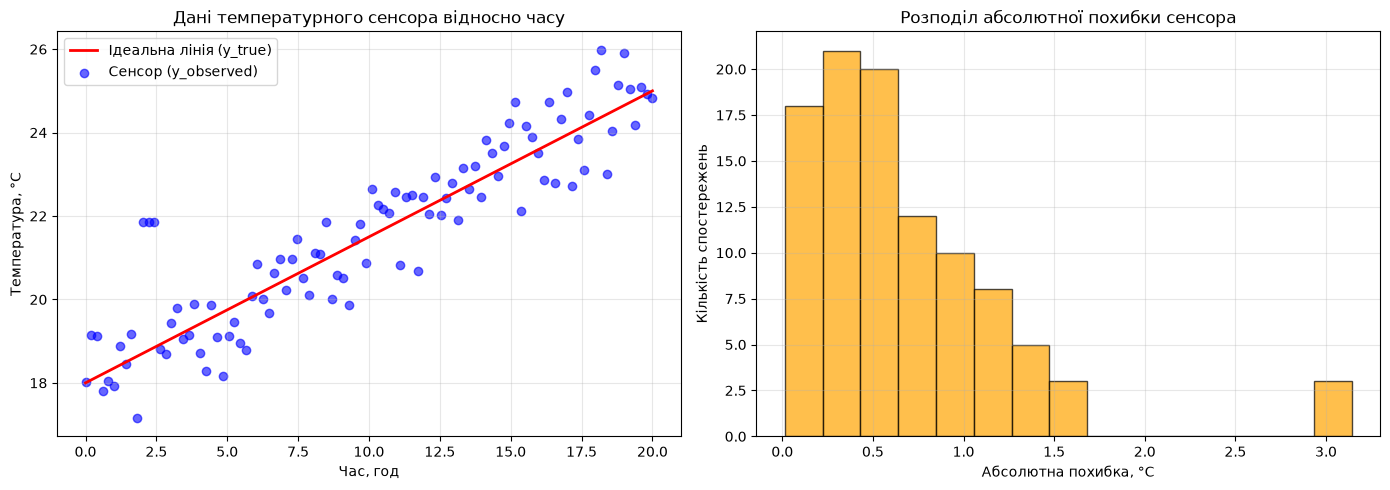

In [7]:
# 3.3 Побудова графіків
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Лінія ідеальних значень та точки спостережень
ax[0].plot(df['x'], df['y_true'], color='red', label='Ідеальна лінія (y_true)', linewidth=2)
ax[0].scatter(df['x'], df['y_observed'], color='blue', alpha=0.6, label='Сенсор (y_observed)')
ax[0].set_title('Дані температурного сенсора відносно часу')
ax[0].set_xlabel('Час, год')
ax[0].set_ylabel('Температура, °C')
ax[0].grid(alpha=0.3)
ax[0].legend()

# Графік 2: Гістограма абсолютних похибок
ax[1].hist(df['absolute_error'], bins=15, color='orange', edgecolor='black', alpha=0.7)
ax[1].set_title('Розподіл абсолютної похибки сенсора')
ax[1].set_xlabel('Абсолютна похибка, °C')
ax[1].set_ylabel('Кількість спостережень')
ax[1].grid(alpha=0.3)

plt.tight_layout()

# Збереження рисунку
plt.savefig('Lab2_plot.png', dpi=300)
plt.show()

**Висновок (Метрики та Графіки):**
Обидві метрики є невід'ємними. МАЕ показує, що в середньому сенсор помиляється на ~0.64 °C (одиниці вимірювання збігаються з цільовою змінною). MSE сильніше штрафує великі відхилення. Візуально на графіку видно, що точки вимірювань рівномірно "розкидані" навколо ідеальної лінії тренду через доданий нормальний білий шум.

In [8]:
# Збереження результатів
df.to_csv('Lab2_results.csv', index=False)
df.to_parquet('Lab2_results.parquet', index=False)
agg_df.to_csv('Lab2_summary.csv')

# Перевірка зчитування
df_reloaded = pd.read_csv('Lab2_results.csv')
print(f"Форма вихідного DataFrame: {df.shape}")
print(f"Форма зчитаного DataFrame: {df_reloaded.shape}")

Форма вихідного DataFrame: (100, 7)
Форма зчитаного DataFrame: (100, 7)


## Підсумковий висновок
Під час виконання лабораторної роботи було створено імітаційні дані температурного сенсора за допомогою NumPy. Ми навчилися виконувати агрегації та маніпуляції з матрицями. За допомогою бібліотеки pandas дані були перетворені у зручний табличний формат, очищені від штучно створених пропусків та дублікатів. Обчислені метрики якості (MAE ≈ 0.64 °C, MSE ≈ 0.65) та графіки Matplotlib продемонстрували наявність нормального шуму в даних датчика. Збереження у форматах CSV та Parquet підтвердило цілісність пайплайну обробки даних.